In [1]:
import json
import requests

In [3]:
URLS = {
    "AllPricesToday": "https://mtgjson.com/api/v5/AllPricesToday.json.gz",
    "AllPrices": "https://mtgjson.com/api/v5/AllPrices.json.gz",
    "AllPrintings": "https://mtgjson.com/api/v5/AllPrintings.json.gz",
    "AllSets": "https://mtgjson.com/api/v5/AllSets.json.gz",
    "AllStandardCards": "https://mtgjson.com/api/v5/AllStandardCards.json.gz",
    "AllTokens": "https://mtgjson.com/api/v5/AllTokens.json.gz",
    "AllTypes": "https://mtgjson.com/api/v5/AllTypes.json.gz",
}

In [4]:
requests.get(URLS["AllPricesToday"])
# download the file
import gzip
import os

def download_file(url, filename):
    response = requests.get(url)
    # Yes, you can unzip (decompress) the gzipped response in memory before writing it to a file.
    # Here's how to do it:
    if url.endswith(".gz"):
        decompressed_content = gzip.decompress(response.content)
        with open(filename, "wb") as f:
            f.write(decompressed_content)
        return
    
    with open(filename, "wb") as f:
        f.read()
        f.write(response.content)

def download_all_files():
    for url in URLS.values():
        filename = url.split("/")[-1]
        download_file(url, filename)

download_file(URLS["AllPricesToday"], "AllPricesToday.json")



In [42]:
import json
with open("AllPricesToday.json", "r") as f:
    data = json.load(f)

data


{'meta': {'date': '2025-12-14', 'version': '5.2.2+20251214'},
 'data': {'f182e364-0439-5594-a6e6-75f7889ccf45': {'mtgo': {'cardhoarder': {'buylist': {},
     'retail': {'normal': {'2025-12-14': 0.17}},
     'currency': 'USD'}}},
  '330deaa3-dd7a-52a8-bfbc-b323cd16a409': {'mtgo': {'cardhoarder': {'buylist': {},
     'retail': {'normal': {'2025-12-14': 0.33}},
     'currency': 'USD'}}},
  '79e36956-b91f-580f-8309-7d9585a67560': {'mtgo': {'cardhoarder': {'buylist': {},
     'retail': {'normal': {'2025-12-14': 0.02}},
     'currency': 'USD'}}},
  '6afb2b4c-530a-57d5-8e7f-871239f6fa05': {'mtgo': {'cardhoarder': {'buylist': {},
     'retail': {'normal': {'2025-12-14': 0.29}},
     'currency': 'USD'}}},
  'b1fc2762-92aa-5a14-8509-a59cb611e376': {'mtgo': {'cardhoarder': {'buylist': {},
     'retail': {'normal': {'2025-12-14': 0.02}},
     'currency': 'USD'}}},
  '1752875e-efd2-55fb-a43b-0ddfa14fdb38': {'mtgo': {'cardhoarder': {'buylist': {},
     'retail': {'normal': {'2025-12-14': 0.23}},
   

In [46]:
import psutil
import time
# psutil.cpu_percent()
# Get the process info for the current Python process
process = psutil.Process(os.getpid())
# Get the memory info
while True:
    time.sleep(1)
    print(process.memory_percent())
# process.memory_percent()

2.9573440551757812
2.9573440551757812


KeyboardInterrupt: 

In [44]:
cards = data["data"]
foil_count = 0
total = 0
for k, v in cards.items():
    if "paper" in v:
        total += 1
        for source, mapping in v["paper"].items():
            if "retail" in mapping and "foil" in mapping["retail"]:
                foil_count += 1
                break
print(f"{foil_count}/{total} have foil prices: {foil_count/total*100}%")

69476/100886 have foil prices: 68.8658485815673%


ok so we have a mapping from card ids -> paper/mtgo -> sources -> price type (we want retail)-> card type (foil, etc) -> price, currency 

In [50]:
card_types = set()
for card_id, card_info in cards.items():
    if "paper" not in card_info:
        continue
    for source, mapping in card_info["paper"].items():
        if "retail" not in mapping:
            continue
        for card_type, price_info in mapping["retail"].items():
            card_types.add(card_type)
print(f"Unique card types: {card_types}")
        

Unique card types: {'normal', 'etched', 'foil'}


In [51]:
# Unique source types
source_types = set()
for card_id, card_info in cards.items():
    if "paper" not in card_info:
        continue
    for source, mapping in card_info["paper"].items():
        source_types.add(source)
print(f"Unique source types: {source_types}")

Unique source types: {'tcgplayer', 'cardmarket', 'cardkingdom', 'cardsphere', 'manapool'}


In [59]:
# Unique prices
prices = []
for card_id, card_info in cards.items():
    if "paper" not in card_info:
        continue
    for source, mapping in card_info["paper"].items():
        if "retail" not in mapping:
            continue
        for card_type, price_info in mapping["retail"].items():
            for date, price in price_info.items():
                if mapping["currency"] == "USD":
                    prices.append(price)
                    if price > 10000:
                        print(f"{card_id} {card_type} {date} {price}")
print(f"Unique prices: {list(sorted(prices, reverse=True))}")


1c17ce18-bf3e-558b-9389-632588f93851 normal 2025-12-14 20460.0
d4d8c9f9-31ed-53ed-ab67-eba86e2198fe normal 2025-12-14 50219.07
d4d8c9f9-31ed-53ed-ab67-eba86e2198fe normal 2025-12-14 106305.88
3876cd4c-db88-534e-877c-307fa2e2b160 normal 2025-12-14 17999.99
25292565-ce32-5533-a526-ce41d41c0516 normal 2025-12-14 12999.99
25292565-ce32-5533-a526-ce41d41c0516 normal 2025-12-14 18599.07
5dd1158c-6210-5a8c-a9bb-63df7f25d10a normal 2025-12-14 13926.75
daae9119-9316-538f-b9ae-ba871f5cb185 normal 2025-12-14 18507.0
6306bc8b-629a-5487-828c-b3d757972728 normal 2025-12-14 10741.49
02e9bfa7-3a9c-5431-9465-21e0b34f865c foil 2025-12-14 10420.0
cd845e02-8333-5476-9a55-14071a11fdcd normal 2025-12-14 21830.84
63020af6-192a-52de-ab67-7afaa76c9c63 normal 2025-12-14 13999.99
63020af6-192a-52de-ab67-7afaa76c9c63 normal 2025-12-14 12043.35
7415e72a-f2f7-53e5-bcec-0a8c61ff3a15 normal 2025-12-14 55799.07
7415e72a-f2f7-53e5-bcec-0a8c61ff3a15 normal 2025-12-14 19908.45
ff19b91f-c815-558a-897a-4b8c4f3e61db normal 

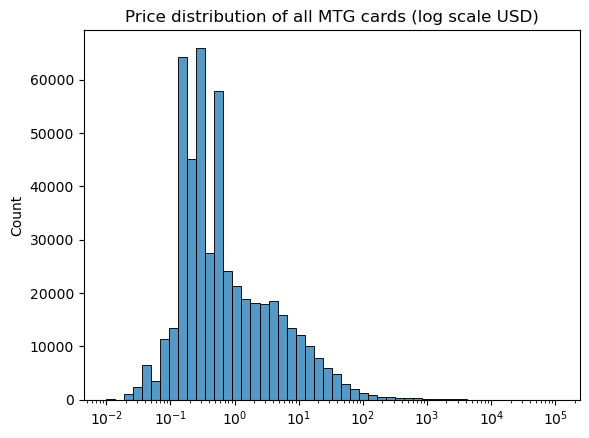

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(prices, log_scale=True, bins=50)
# add title
plt.title("Price distribution of all MTG cards (log scale USD)")
plt.show()


In [61]:
# Get median price
import numpy as np
median_price = np.median(prices)
print(f"Median price: {median_price}")


Median price: 0.49


In [1]:
import sys
sys.path.append("..")
from mtg_json.loader import MTGJsonLoader
loader = MTGJsonLoader()
data = loader.load_mtg_json("AllPrintings")


In [20]:
datesets = {}
import datetime as dt
def strtodt(dstr: str) -> dt.date:
    year, month, date = dstr.split("-")
    return dt.date(year = int(year), month = int(month), day = int(date))

for set_abv, set_data in data["data"].items():
    datesets[set_data["name"]] = strtodt(set_data["releaseDate"])

sets = list(sorted(datesets.keys(), key=lambda key: datesets[key]))
for s in sets:
    print(s, datesets[s])

Limited Edition Alpha 1993-08-05
Limited Edition Beta 1993-10-04
Unlimited Edition 1993-12-01
Collectors' Edition 1993-12-10
Intl. Collectors' Edition 1993-12-10
Arabian Nights 1993-12-17
Antiquities 1994-03-04
Revised Edition 1994-04-11
Foreign Black Border 1994-04-11
Foreign White Border 1994-04-11
Legends 1994-06-01
Summer Magic / Edgar 1994-06-21
Dragon Con 1994-07-15
The Dark 1994-08-01
HarperPrism Book Promos 1994-09-01
Fallen Empires 1994-11-01
Media and Collaboration Promos 1995-01-01
Fourth Edition Foreign Black Border 1995-04-01
Fourth Edition 1995-04-01
Ice Age 1995-06-03
Chronicles Foreign Black Border 1995-07-01
Chronicles 1995-07-01
Renaissance 1995-08-01
Rinascimento 1995-08-01
Homelands 1995-10-01
Oversized 90's Promos 1996-04-01
Pro Tour Collector Set 1996-05-01
Alliances 1996-06-10
DCI Legend Membership 1996-07-01
Rivals Quick Start Set 1996-07-01
Arena League 1996 1996-08-02
Celebration Cards 1996-08-14
Redemption Program 1996-10-01
Mirage 1996-10-08
Multiverse Gift 

In [31]:
def print_card_details(card):
    print(card.keys())
    print(card["manaCost"])
    print(card["colors"])

for set_abv, set_data in data["data"].items():
    card = set_data["cards"][0]
    print_card_details(card)
    break

dict_keys(['artist', 'artistIds', 'availability', 'boosterTypes', 'borderColor', 'colorIdentity', 'colors', 'convertedManaCost', 'edhrecRank', 'edhrecSaltiness', 'finishes', 'foreignData', 'frameVersion', 'hasFoil', 'hasNonFoil', 'identifiers', 'isReprint', 'keywords', 'language', 'layout', 'legalities', 'manaCost', 'manaValue', 'name', 'number', 'originalText', 'power', 'printings', 'purchaseUrls', 'rarity', 'setCode', 'sourceProducts', 'subtypes', 'supertypes', 'text', 'toughness', 'type', 'types', 'uuid', 'variations'])
{5}{W}{W}
['W']


How do I want to organize this database?

Set info -> set_id, set_name, release_date
Card info -> cid, set_id, card_name, etc... lots of details here
Pricing info -> pricing_id, c_id, source, pricing_dt



Sets: set_id, realeaseDate
Cards: card_id, set_id, rarity, etc
    detail here : https://mtgjson.com/data-models/card/card-atomic/
Pricings: pricing_id, card_id, source, price, currency

In [1]:
import sys
from typing import List
sys.path.append("..")
from mtg_json.loader import MTGJsonLoader
from mtg_json.types import SetInfo

loader = MTGJsonLoader()
# all_printings = loader.load_mtg_json("AllPrintings")
# cards = loader.load_cards()
# print(len(cards))

In [5]:
prices = loader.load_prices()

In [25]:
import numpy as np
paper_prices = []
for price in prices.values():
    if price.paper is None:
        continue
    normal_prices = []
    for pricelist in price.paper.values():
        if not pricelist.retail:
            continue
        if pricelist.retail.normal is None:
            continue
        if pricelist.currency != "USD":
            continue
        for price in pricelist.retail.normal.values():
            normal_prices.append(price)
    if normal_prices:
        paper_prices.append(np.mean(normal_prices))

print(len(paper_prices))


87097


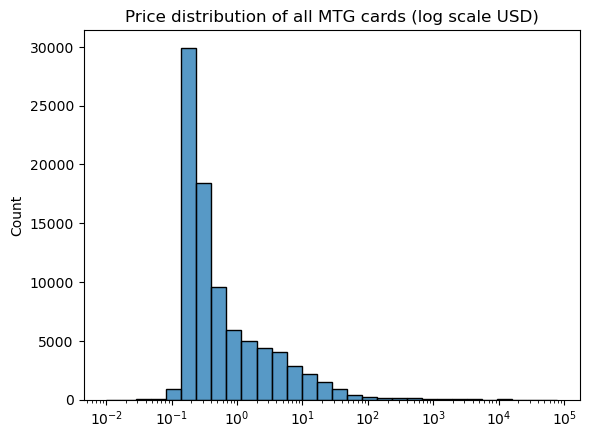

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(paper_prices, log_scale=True, bins=30)
plt.title("Price distribution of all MTG cards (log scale USD)")
plt.show()

In [27]:
np.median(paper_prices)

np.float64(0.33)

In [29]:
np.mean(paper_prices)

np.float64(12.94886317362634)